### Data Science 2025/26 Coursework
## Oliver Mann

The data science part of the coursework requires a sample set of images of handwritten digits and letters

Q1 - data visualisation and classification

Q2 - ML and data classification (logistic regression, KNN, random forrest)

In [ ]:
#  Data Science

import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

np.set_printoptions(threshold=sys.maxsize) # remove at submission. Shows full np array
np.random.seed(42)

data = np.load('image_data.npz')
train_X = data['train_X']
train_Y = data['train_Y']
test_X = data['test_X']
test_Y = data['test_Y']

Train X samples: 11280, Test X samples: 1880
Train X features: 784, Test X features: 784
Train Y samples: 11280, Test Y samples: 1880
Train X mean: 44.426237, Train X std: 84.796030


Text(0.5, 1.0, 'Population of different classes')

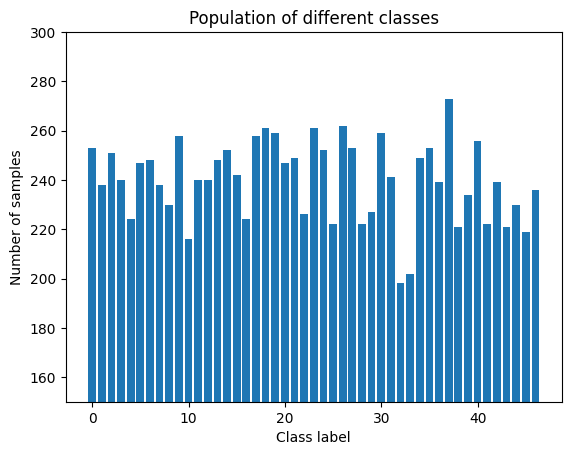

In [ ]:
# Question 1

# ===  1A ===

# desciptive statistics
print(f'Train X samples: {train_X.shape[0]}, Test X samples: {test_X.shape[0]}')
print(f'Train X features: {train_X.shape[1]}, Test X features: {test_X.shape[1]}')
print(f'Train Y samples: {train_Y.shape[0]}, Test Y samples: {test_Y.shape[0]}')
print(f'Train X mean: {train_X.mean():2f}, Train X std: {train_X.std():2f}')

# compare population of different classes
classes = train_Y
classes_unique, count = np.unique(classes, return_counts=True)

fig1, ax1 = plt.subplots()
ax1.bar(range(len(classes_unique)),count)
ax1.set_ybound(150, 300)
ax1.set_xlabel('Class label')
ax1.set_ylabel('Number of samples')
ax1.set_title('Population of different classes')

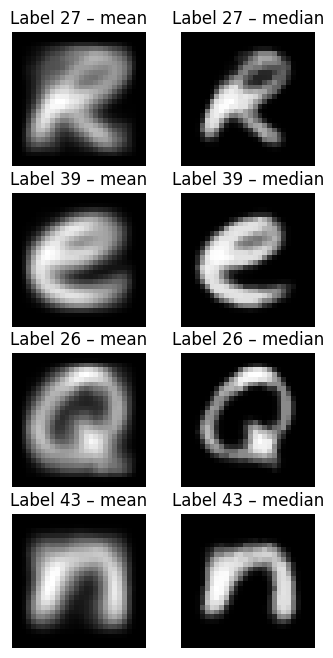

In [ ]:
# === 1B ===
    # -> visualise 4 label classes

# sort images into their classes
sorted_classes = []
for label in classes_unique:
    images = train_X[train_Y.flatten() == label]
    sorted_classes.append(images)

# select 4 random sample classes
samples = np.random.choice(classes_unique, 4, replace=False)

# visulaise each class
dimension = int(np.sqrt(train_X.shape[1])) # images are square
fig2, ax2 = plt.subplots(len(samples), 2, figsize=(4, 2 * len(samples)))

for row, sample in enumerate(samples):
    class_images = sorted_classes[sample]
    mean_image = np.mean(class_images, axis=0)
    mean_image = mean_image.reshape(dimension, dimension).T
    median_image = np.median(class_images, axis=0)
    median_image = median_image.reshape(dimension, dimension).T

    ax2[row, 0].imshow(mean_image, cmap='gray')
    ax2[row, 0].set_title(f"Label {sample} – mean")
    ax2[row, 0].axis('off')
    ax2[row, 1].imshow(median_image, cmap='gray')
    ax2[row, 1].set_title(f"Label {sample} – median")
    ax2[row, 1].axis('off')    


'\n- this 2D projection of two classses could be used to verify a linear seperability, \n    as the classes will have linearly correlated features\n- if both clusters of points are mostly seperated and a line can be drawn between \n    them, they are likely linearly seperable\n- if there is a heavy overlap in the clouds, this suggests points are unlikely to be \n    linearly seperable\n'

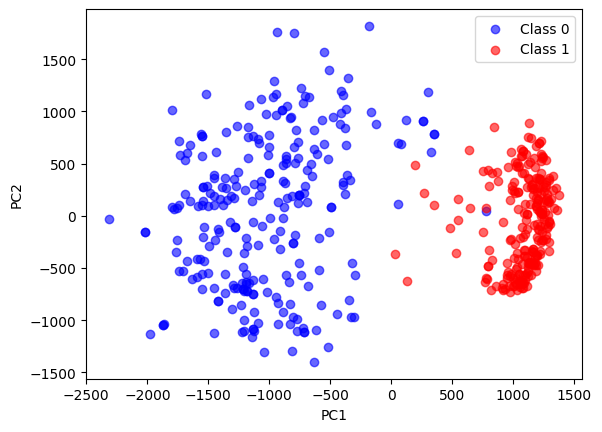

In [ ]:
# === 1C ===
    # -> visualise training data of 2 classes in 2 dimensions
    # -> are they linerarly seperable?

# generate sample
s0 = sorted_classes[0]
s1 = sorted_classes[1]
n0 = s0.shape[0] # no. of samples in class
S = np.vstack([s0, s1])

pca = PCA(n_components=2)
S_pca = pca.fit_transform(S)
S0_pca = S_pca[:n0]  
S1_pca = S_pca[n0:]

fig3, ax3 = plt.subplots()
ax3.scatter(S0_pca[:, 0], S0_pca[:, 1], c= 'b', alpha=0.6, label="Class 0")
ax3.scatter(S1_pca[:, 0], S1_pca[:, 1], c= 'r', alpha=0.6, label="Class 1")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.legend()

'''
- this 2D projection of two classses could be used to verify a linear seperability, 
    as the classes will have linearly correlated features
- if both clusters of points are mostly seperated and a line can be drawn between 
    them, they are likely linearly seperable
- if there is a heavy overlap in the clouds, this suggests points are unlikely to be 
    linearly seperable
'''


238 238
Mean euclid distance of subset 1: 131.645368
Mean euclid distance of subset 2: 177.567543


"\n- the euclidian distance should be lower on average for subset 1, containing 1 class\n    because the distance between letters and digits within the same class in the data \n    set will be less\n- subset 2's images will vary more, and have a higher euclidian distance average\n    as a result\n- this is reflected in the histograms, where subset 1 has a peak at a lower distance\n"

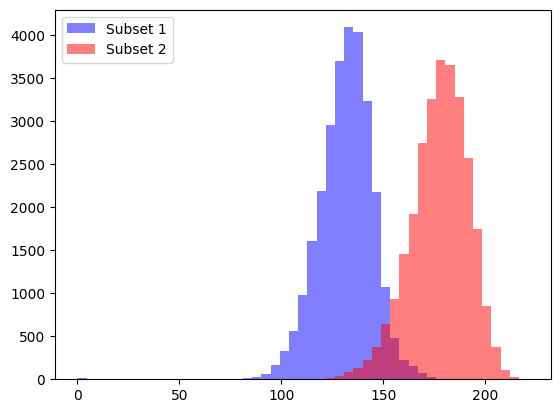

In [ ]:
# === 1D ===
    # -> use a metric to measure similarity of 2 images

def euclid_dist(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

subset1 = sorted_classes[1]  # subset of data containing one class

# collect random features from the remaining training data
# check subset2 is the same size as subset 1
idx = np.random.choice(train_X.shape[0], size=len(subset1), replace=False)
subset2 = train_X[idx] 
print(len(subset1), len(subset2))

# compute euclidian distance for each combination of images
dists1, dists2 = [] , []

for i in range(len(subset1)):
    for j in range(i+1, subset1.shape[0]):
            dists1.append(euclid_dist(subset1[i], subset1[j]))
            dists2.append(euclid_dist(subset2[i], subset2[j]))

# plot euclidian distances of both subset 1 and 2
# histograms have same bin sizes and edges to make comparisons
fig4, ax4 = plt.subplots()
all_dists = np.hstack((dists1, dists2))
nbins = 50
bin_edges = np.linspace(all_dists.min(), all_dists.max(), nbins)

ax4.hist(dists1, bins=bin_edges, alpha=0.5, color='b', label='Subset 1')
ax4.hist(dists2, bins=bin_edges, alpha=0.5, color='r', label='Subset 2') 
ax4.legend()

print(f'Mean euclid distance of subset 1: {np.mean(dists1):3f}')
print(f'Mean euclid distance of subset 2: {np.mean(dists2):3f}')

'''
- the euclidian distance should be lower on average for subset 1, containing 1 class
    because the distance between letters and digits within the same class in the data 
    set will be less
- subset 2's images will vary more, and have a higher euclidian distance average
    as a result
- this is reflected in the histograms, where subset 1 has a peak at a lower distance
'''


In [ ]:
# Question 2

# Create subset of test/train data set with only two classes
class_subset = [2, 35]
# images of '2' and 'Z' chosen so that classes are not too easily seperable to
#   test classifying models in more depth

train_idx = np.isin(train_Y.flatten(), class_subset)
test_idx = np.isin(test_Y.flatten(), class_subset)

subtrain_X = train_X[train_idx]
subtrain_Y = train_Y[train_idx].flatten()
subtest_X = test_X[test_idx]
subtest_Y = test_Y[test_idx].flatten()

In [ ]:
# === 2A ===
      # -> train model for each of the classifiers
      # -> select optimal hyperparameters

# (i)
logreg = LogisticRegression()
knn = neighbors.KNeighborsClassifier()
randforest = RandomForestClassifier()

models = [logreg, knn, randforest]
model_names = ['logistic regression', 'knn', 'random forest']

# fit models on training set using defualt paramaters
for i in range(len(models)):
    model = models[i]
    model_name = model_names[i]

    model.fit(subtrain_X, subtrain_Y)
    subtrain_Ypred = model.predict(subtrain_X)
    subtest_Ypred = model.predict(subtest_X)

    train_cm = confusion_matrix(subtrain_Y, subtrain_Ypred)
    test_cm = confusion_matrix(subtest_Y, subtest_Ypred)
    print(model_name, 'test confustion matrix: ')
    print(test_cm)

    acc_train = np.diag(train_cm).sum()/train_cm.sum()
    acc_test = np.diag(test_cm).sum()/test_cm.sum()

    print(model_name + f" train accuracy: {acc_train:.4f}, test accuracy: {acc_test:.4f}")

# (ii)

# layout hyperparameter options
logreg_choices = np.logspace(-10, 2, 13)
knn_choices = range(1, 5)

randforest_choices = []
n_estimators = [50, 100, 200]
max_depth = [None, 10, 20, 30]
for n in n_estimators:
    for depth in max_depth:
        randforest_choices.append((n, depth))

logreg_train_acc = np.zeros((len(logreg_choices), 5))
logreg_val_acc = np.zeros((len(logreg_choices), 5))
knn_train_acc = np.zeros((len(knn_choices), 5))
knn_val_acc = np.zeros((len(knn_choices), 5))
randforest_train_acc = np.zeros((len(randforest_choices), 5))
randforest_val_acc = np.zeros((len(randforest_choices), 5))

# split data into 5 folds
kfold = KFold(5)

# train each model on each fold
# each fold is used for both training and validation
for i, (train_idx, val_idx) in enumerate(kfold.split(subtrain_X)):

    # create i'th folds and split into train and validation
    train_X_fold = subtrain_X[train_idx]
    train_Y_fold = subtrain_Y[train_idx]
    val_X_fold = subtrain_X[val_idx]
    val_Y_fold = subtrain_Y[val_idx]

    # train / val logisitic regression
    for j in range(len(logreg_choices)):
        C = logreg_choices[j]
        logreg.C = C
        logreg.max_iter = 5000
        logreg.fit(train_X_fold, train_Y_fold)

        logreg_pred_train = logreg.predict(train_X_fold)
        logreg_pred_val = logreg.predict(val_X_fold)

        logreg_train_cm = confusion_matrix(train_Y_fold, logreg_pred_train)
        logreg_val_cm = confusion_matrix(val_Y_fold, logreg_pred_val)

        logreg_train_acc[j, i] = np.diag(logreg_train_cm).sum()/logreg_train_cm.sum()
        logreg_val_acc[j, i] = np.diag(logreg_val_cm).sum()/logreg_val_cm.sum()

    # train / val kNN
    for j in range(len(knn_choices)):
        k = knn_choices[j]
        knn.n_neighbors = k
        knn.fit(train_X_fold, train_Y_fold)

        knn_pred_train = knn.predict(train_X_fold)
        knn_pred_val = knn.predict(val_X_fold)

        knn_train_cm = confusion_matrix(train_Y_fold, knn_pred_train)
        knn_val_cm = confusion_matrix(val_Y_fold, knn_pred_val)

        knn_train_acc[j, i] = np.diag(knn_train_cm).sum()/knn_train_cm.sum()
        knn_val_acc[j, i] = np.diag(knn_val_cm).sum()/knn_val_cm.sum()
    
    # train / val random forest
    for j in range(len(randforest_choices)):
        n, depth = randforest_choices[j]
        randforest.n_estimators = n
        randforest.max_depth = depth
        randforest.fit(train_X_fold, train_Y_fold)

        randforest_pred_train = randforest.predict(train_X_fold)
        randforest_pred_val = randforest.predict(val_X_fold)

        randforest_train_cm = confusion_matrix(train_Y_fold, randforest_pred_train)
        randforest_val_cm = confusion_matrix(val_Y_fold, randforest_pred_val)

        randforest_train_acc[j, i] = np.diag(randforest_train_cm).sum()/randforest_train_cm.sum()
        randforest_val_acc[j, i] = np.diag(randforest_val_cm).sum()/randforest_val_cm.sum()

# average accuracies over all folds
logreg_train_acc_avg = logreg_train_acc.mean(axis=1)
logreg_val_acc_avg = logreg_val_acc.mean(axis=1)
knn_train_acc_avg = knn_train_acc.mean(axis=1)
knn_val_acc_avg = knn_val_acc.mean(axis=1)
randforest_train_acc_avg = randforest_train_acc.mean(axis=1)
randforest_val_acc_avg = randforest_val_acc.mean(axis=1)

# find optimal selction of hyperparameters
logreg_idx = np.argmax(logreg_val_acc_avg)
best_logreg = logreg_choices[logreg_idx]
knn_idx = np.argmax(knn_val_acc_avg)
best_knn = knn_choices[knn_idx]
randforest_idx = np.argmax(randforest_val_acc_avg)
best_randforest = randforest_choices[randforest_idx]

print(f'Best Logistic Regression C: {best_logreg}')
print(f'Best kNN k: {best_knn}')
print(f'Best Random Forest (n_estimators, max_depth): {best_randforest}')

# optimal logreg fitted to test data
optim_logreg = LogisticRegression(C=best_logreg)
optim_logreg.fit(subtrain_X, subtrain_Y)

logreg_train_pred = optim_logreg.predict(subtrain_X)
logreg_test_pred  = optim_logreg.predict(subtest_X)

optim_logreg_train_cm = confusion_matrix(subtrain_Y, logreg_train_pred)
optim_logreg_test_cm = confusion_matrix(subtest_Y,  logreg_test_pred)

print("Logistic regression train accuracy:",
      np.diag(optim_logreg_train_cm).sum() / optim_logreg_train_cm.sum())
print("Logistic regression val accuracy:",
      np.diag(optim_logreg_test_cm).sum() / optim_logreg_test_cm.sum())

# optimal kNN fitted to test data
optim_knn = neighbors.KNeighborsClassifier(n_neighbors=best_knn)
optim_knn.fit(subtrain_X, subtrain_Y)

knn_train_pred = optim_knn.predict(subtrain_X)
knn_test_pred  = optim_knn.predict(subtest_X)

optim_knn_train_cm = confusion_matrix(subtrain_Y, knn_train_pred)
optim_knn_test_cm = confusion_matrix(subtest_Y,  knn_test_pred)

print("kNN train accuracy:",
      np.diag(optim_knn_train_cm).sum() / optim_knn_train_cm.sum())
print("kNN test accuracy:",
      np.diag(optim_knn_test_cm).sum() / optim_knn_test_cm.sum())

# optimal rand forrest fitted to test data
optim_n, optim_depth = best_randforest
optim_randforest = RandomForestClassifier(n_estimators=optim_n, max_depth=optim_depth, random_state=0)
optim_randforest.fit(subtrain_X, subtrain_Y)

randforest_train_pred = optim_randforest.predict(subtrain_X)
randforest_test_pred  = optim_randforest.predict(subtest_X)

optim_randforest_train_cm = confusion_matrix(subtrain_Y, randforest_train_pred)
optim_randforest_test_cm = confusion_matrix(subtest_Y,  randforest_test_pred)

print("Random forest train accuracy:",
      np.diag(optim_randforest_train_cm).sum() / optim_randforest_train_cm.sum())
print("Random forest test accuracy:", 
      np.diag(optim_randforest_test_cm).sum() / optim_randforest_test_cm.sum())

'''
All 3 classifiers in (i) have a high training accuracy but a lower train accuracy.
This suggests the models fit the training data very well but could be overfitting.

After K fold cross validation
- smaller value of C reults in strong regulisation and reduces overfitting for logreg, shown by the
      smaller difference between train and test accuracies. The similar test accuracies suggests that
      performance is unchaged by CV
- for kNN, training accuracy increases to 1  and test accuracy also improves, suggesting the data
      is clustered and nearest neighbour classification is effective
- for random forest, the number of estimators and depth of trees are reduced to prevent overfitting,
      marginally improving the overall performance of the model

The biggest improvement in perfomance is seen in kNN optimisation.
To impove K fold CV, more hyperparameters could be optimised to improve the perfomance of the models.
'''

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic regression test confustion matrix: 
[[34  9]
 [ 5 48]]
logistic regression train accuracy: 1.0000, test accuracy: 0.8542
knn test confustion matrix: 
[[32 11]
 [ 2 51]]
knn train accuracy: 0.9087, test accuracy: 0.8646
random forest test confustion matrix: 
[[35  8]
 [ 4 49]]
random forest train accuracy: 1.0000, test accuracy: 0.8750
Best Logistic Regression C: 1e-06
Best kNN k: 1
Best Random Forest (n_estimators, max_depth): (100, 30)
Logistic regression train accuracy: 0.8968253968253969
Logistic regression val accuracy: 0.8541666666666666
kNN train accuracy: 1.0
kNN test accuracy: 0.8854166666666666
Random forest train accuracy: 1.0
Random forest test accuracy: 0.875


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


'\nAll 3 classifiers in (i) have a high training accuracy but a lower train accuracy.\nThis suggests the models fit the training data very well but could be overfitting.\n\nAfter K fold cross validation\n- smaller value of C reults in strong regulisation and reduces overfitting for logreg, shown by the\n      smaller difference between train and test accuracies. The similar test accuracies suggests that\n      performance is unchaged by CV\n- for kNN, training accuracy increases to 1  and test accuracy also improves, suggesting the data\n      is clustered and nearest neighbour classification is effective\n- for random forest, the number of estimators and depth of trees are reduced to prevent overfitting,\n      marginally improving the overall performance of the model\n\nThe biggest improvement in perfomance is seen in kNN optimisation.\nTo impove K fold CV, more hyperparameters could be optimised to improve the perfomance of the models.\n'

In [ ]:
# === 2B ===
    # -> K-means to seperate 2 classes of the data


# seperate test data into 2 clusters
subset_data = np.vstack([subtrain_X, subtest_X])
subset_lables = np.hstack([subtrain_Y, subtest_Y])

# apply Kmeans clustering
kmeans = KMeans(n_clusters=2).fit(subtest_X)
kmeans_lables = kmeans.labels_

# match subtest data to the kmeans_labels
for i in range(len(subtest_Y)):
    if subtest_Y[i] == 2:
        subtest_Y[i] = 0
    else:
        subtest_Y[i] = 1

cm = confusion_matrix(subtest_Y, kmeans_lables)
acc1 = (cm[0,0] + cm[1,1])/cm.sum()
acc2 = (cm[0,1] + cm[1,0])/cm.sum()
accuracy = max(acc1, acc2)
#print(acc1, acc2)
print(f'Kmeans clustering accuracy: {accuracy}')

print(cm)

'''
Kmeans clusters don't perform as well as other clasifiers,
because it is unsupervised.
The 2 classes may not be in distinct clouds, leading to a low accuracy score.
'''



Kmeans clustering accuracy: 0.7291666666666666
[[31 12]
 [14 39]]


"\nKmeans clusters don't perform as well as other clasifiers,\nbecause it is unsupervised.\nThe 2 classes may not be in distinct clouds, leading to a low accuracy score.\n"